In [1]:
!pip install ultralytics roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 36.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 20.1 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 68.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211

In [2]:
import os
import yaml
import ipywidgets as widgets
import cv2
import numpy as np
from pathlib import Path
from ultralytics import YOLO
from roboflow import Roboflow
from IPython.display import display, Image, clear_output
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

os.environ['WANDB_DISABLED'] = 'true'

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
rf = Roboflow(api_key="hjsXWe8g4NIDan5m5q41")
project = rf.workspace("players-tracking").project("nfl-player-hskqe")
version = project.version(2)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to NFL-Player-2 in yolov11:: 100%|██████████| 19805/19805 [00:01<00:00, 9999.47it/s] 


In [4]:
data_config = {
    'path': './NFL-Player-2', 
    'train': 'train/images',
    'val': 'valid/images', 
    'test': 'test/images', 
    'names': {0: 'Players', 1: 'Referee'},
}

yaml_path = './NFL-Player-2/data.yaml'
with open(yaml_path, 'w') as yaml_file:
    yaml.dump(data_config, yaml_file, default_flow_style=False)

In [5]:
model = YOLO('yolov10m.pt')

results = model.train(
    data=yaml_path,
    epochs=100,
    imgsz=512, 
    device=[0, 1],
    amp=True,
    patience=10,
    batch=64,
)

Ultralytics 8.4.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./NFL-Player-2/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False,

     60/100      10.3G     0.8501     0.3388      0.856        580        512: 1% ──────────── 1/124 1.2it/s 1.4s<1:42


KeyboardInterrupt: 

Ultralytics 8.4.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10m summary (fused): 136 layers, 15,314,326 parameters, 0 gradients, 58.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 802.1±233.9 MB/s, size: 23.2 KB)
val: Scanning /kaggle/working/NFL-Player-2/valid/labels.cache... 990 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 990/990 148.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 3.4it/s 18.5s0.3s


invalid value encountered in less
invalid value encountered in less


                   all        990      14442       0.93      0.931      0.919      0.774
               Players        990      13814      0.953      0.954       0.95      0.799
               Referee        479        628      0.908      0.908      0.889       0.75
Speed: 0.6ms preprocess, 14.0ms inference, 0.0ms loss, 0.2ms postprocess per image
Results saved to /kaggle/working/runs/detect/val


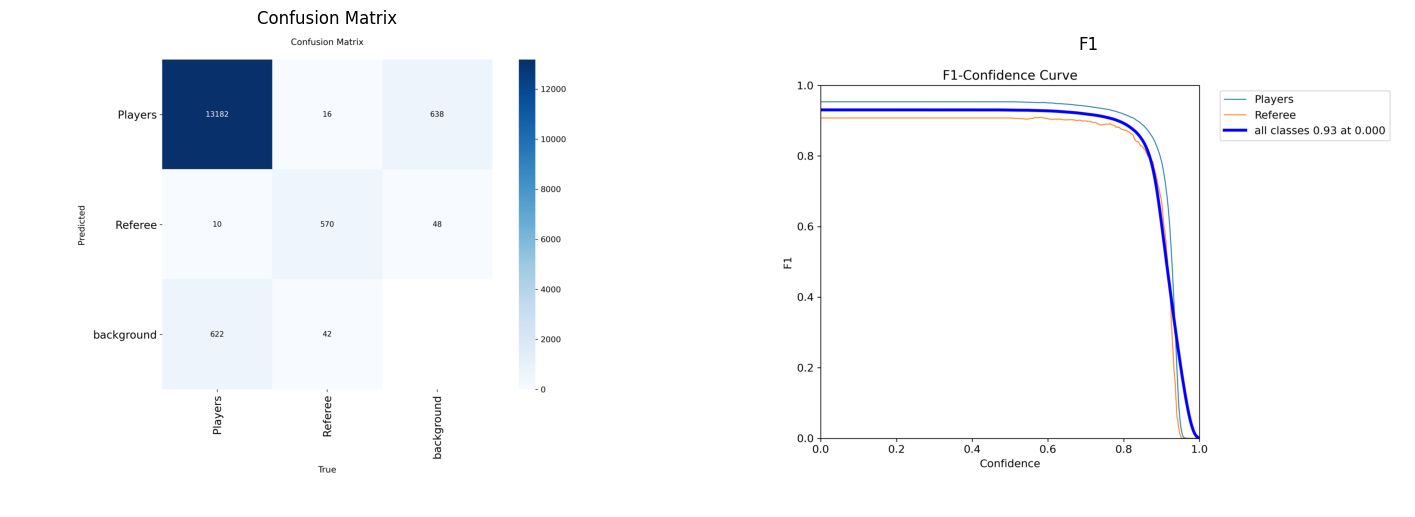

In [11]:
model = YOLO('./runs/detect/train/weights/best.pt')

validation_results = model.val(
    data=yaml_path,
    imgsz=512,
    batch=16, 
    conf=0.5, 
    iou=0.6, 
    device='0' 
)

confusion_matrix = mpimg.imread("./runs/detect/val/confusion_matrix.png")
f1_curve = mpimg.imread("./runs/detect/val/BoxF1_curve.png")

fig, axis = plt.subplots(1, 2, figsize=(18, 8))
axis[0].imshow(confusion_matrix)
axis[0].set_title('Confusion Matrix')
axis[0].axis('off')
axis[1].imshow(f1_curve)
axis[1].set_title('F1')
axis[1].axis('off')
plt.show()

IntSlider(value=0, description='Imagen:', max=989)


image 1/1 /kaggle/working/NFL-Player-2/test/images/Bengals_v_-Redskins_10_100_jpg.rf.d1316b2b7da57e51eb7f5f548b4f6ed4.jpg: 512x512 14 Playerss, 2 Referees, 22.5ms
Speed: 1.5ms preprocess, 22.5ms inference, 0.6ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /kaggle/working/runs/detect/predict-2


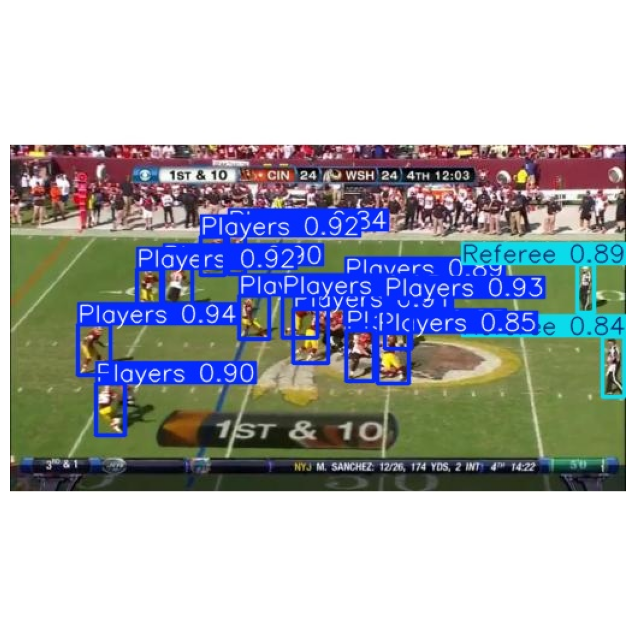

In [12]:
image_folder_path = './NFL-Player-2/test/images'

image_paths = [os.path.join(image_folder_path, img) for img in os.listdir(image_folder_path) 
               if img.endswith(('.png', '.jpg', '.jpeg'))]
num_images = len(image_paths)

slider = widgets.IntSlider(min=0, max=num_images-1, description='Imagen:')
display(slider)

def update_image(change):
    clear_output(wait=True) 
    display(slider) 
    
    imagen_dir = image_paths[change['new']]
    
    model.predict(imagen_dir, save=True, imgsz=512, conf=0.3, show_boxes=True, show_labels=True)
    
    image_path = f"./runs/detect/predict/{os.path.basename(imagen_dir)}"
    
    image = mpimg.imread(image_path)
    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

slider.observe(update_image, names='value')

update_image({'new': slider.value})

In [13]:
path = model.export(
    format="onnx",
    imgsz=512,  
    half=True, 
    dynamic=True,
    simplify=True, 
    nms=False  
)

print(f"Model exported to: {path}")

Ultralytics 8.4.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'runs/detect/train/weights/best.pt' with input shape (1, 3, 512, 512) BCHW and output shape(s) (1, 300, 6) (94.9 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.11.13 environment at: /usr
Resolved 23 packages in 372ms
 Downloaded onnxruntime-gpu
Prepared 3 packages in 3.60s
Uninstalled 1 package in 14ms
Installed 3 packages in 10ms
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91
 - protobuf==3.20.3
 + protobuf==7.34.1

requirements: AutoUpdate success ✅ 4.5s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.18.0 opset 19...


Exporting aten::index operator of advanced indexing in opset 19 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.91...
ONNX: converting to FP16...
ONNX: export success ✅ 10.4s, saved as 'runs/detect/train/weights/best.onnx' (29.9 MB)

Export complete (11.2s)
Results saved to /kaggle/working/runs/detect/train/weights
Predict:         yolo predict task=detect model=runs/detect/train/weights/best.onnx imgsz=512 half
Validate:        yolo val task=detect model=runs/detect/train/weights/best.onnx imgsz=512 data=NFL-Player-2/data.yaml half 
Visualize:       https://netron.app
Model exported to: runs/detect/train/weights/best.onnx
